In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.decomposition import PCA


def build_map_indexes(norm_abx, norm_small_mols):
    # Create mapping from antibiotic and small molecule names to their respective embedding indices
    abx_to_index = pd.Series(norm_abx.index, index=norm_abx['abx_name']).to_dict()
    small_mol_to_index = pd.Series(norm_small_mols.index, index=norm_small_mols['cp_name']).to_dict()
    return abx_to_index, small_mol_to_index


In [7]:
PATH_TO_PREDICTIOS = '../data/unknown_combs'
pred_dir = [
    f'{PATH_TO_PREDICTIOS}/Ab17978_predictions.csv',
    f'{PATH_TO_PREDICTIOS}/Kp43816_predictions.csv',
    f'{PATH_TO_PREDICTIOS}/PAO1_predictions.csv',
    f'{PATH_TO_PREDICTIOS}/AbLac4_predictions.csv',
    f'{PATH_TO_PREDICTIOS}/Kp0087_predictions.csv', 
    f'{PATH_TO_PREDICTIOS}/Pa0095_predictions.csv',
 ]


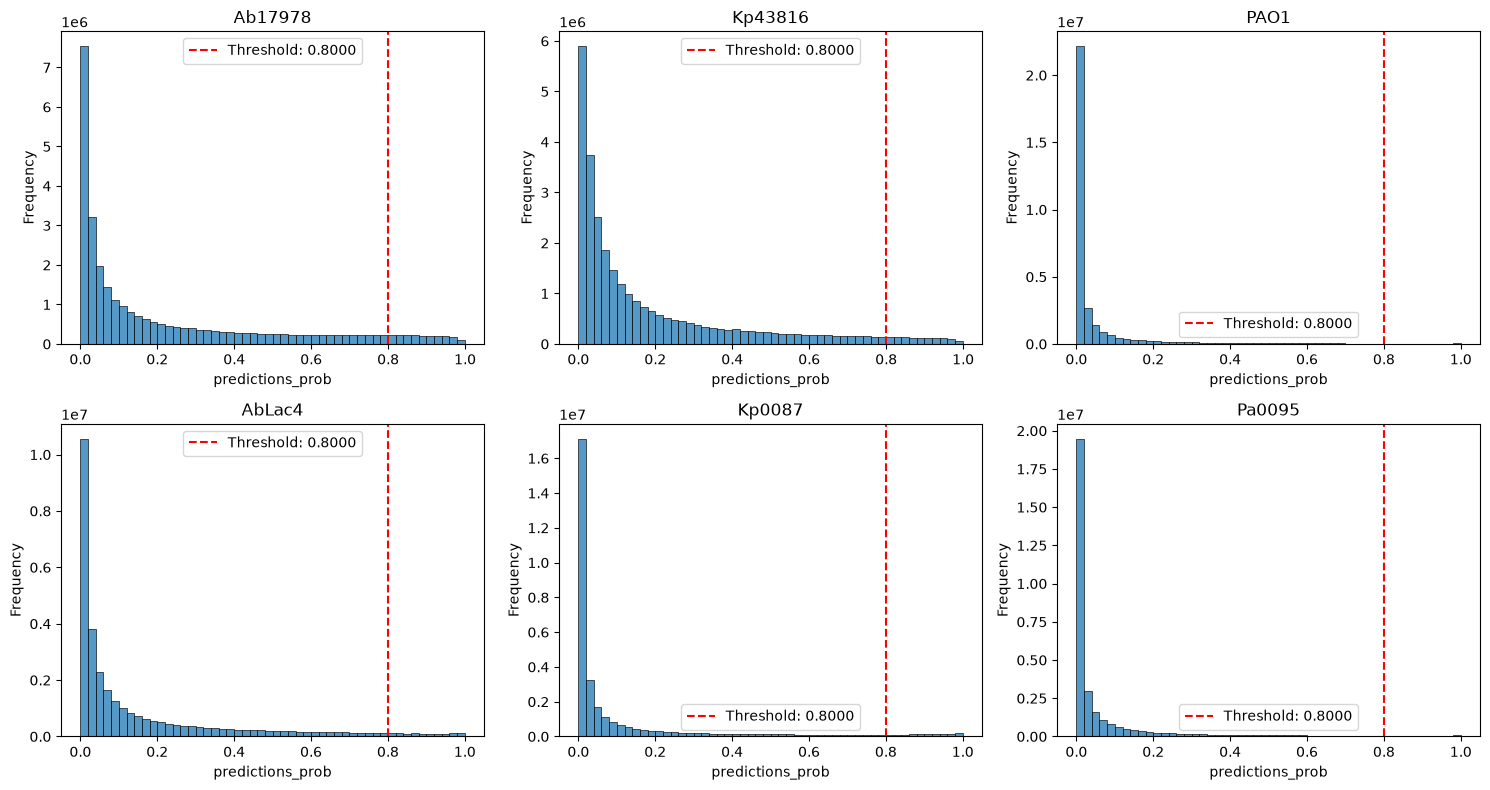

In [9]:
fig, axes = plt.subplots(2,3, figsize=(15, 8))
axes = axes.flatten()

for i, file in enumerate(pred_dir):
    df = pd.read_csv(file)
    strain_name = file.split('/')[-1].split('_')[0]
    sns.histplot(df['predictions_prob'], bins=50, ax=axes[i], stat="frequency")
    axes[i].set_title(strain_name)

    threshold = 0.8
    axes[i].axvline(threshold, color='red', linestyle='--', label=f'Threshold: {threshold:.4f}')
    axes[i].legend()
plt.tight_layout()

In [11]:
non_additive = []
for i, file in enumerate(pred_dir):
    df = pd.read_csv(file)
    strain_name = os.path.basename(file).split('_')[0]

    threshold = 0.8
    count_size = df[df['predictions_prob'] >= threshold].shape[0]
    print(f"{strain_name}Number of predictions above threshold: {count_size} ({count_size/len(df)*100:.2f}%)")

    # Add a column with strain name to the DataFrame
    df['strain_name'] = strain_name
    # Add the strain name and count size to the list
    non_additive.append(df[df['predictions_prob'] >= threshold])

# stack all DataFrames in the list into a single DataFrame
non_additive_df = pd.concat(non_additive, ignore_index=True)

Ab17978Number of predictions above threshold: 39343 (6.66%)
Kp43816Number of predictions above threshold: 23069 (3.98%)
PAO1Number of predictions above threshold: 6609 (1.03%)
AbLac4Number of predictions above threshold: 21494 (3.42%)
Kp0087Number of predictions above threshold: 26075 (4.07%)
Pa0095Number of predictions above threshold: 10366 (1.64%)


In [12]:
# Gruop by strain
comb_strain = non_additive_df.groupby('strain_name').size().reset_index(name='count')

# Group by antibiotic and small molecule and count the number of strains for each combination
abx_cp_counts = non_additive_df.groupby(['abx_name', 'cp_name']).size().reset_index(name='count')

# Filter combinations that are present in all strains, which count is equal to the number of strains (len(pred_dir))
abx_cp_counts = abx_cp_counts[abx_cp_counts['count'] == len(pred_dir)]

# List of antibiotics and small molecules that are present in all strains
abx_always_present = abx_cp_counts.abx_name.unique()
sm_always_present = abx_cp_counts.cp_name.unique()

In [13]:
abx_cp_counts.abx_name.value_counts()

abx_name
DOX    12
TET    12
AZE     3
LIN     2
MOX     2
SFA     1
Name: count, dtype: int64

In [14]:
abx_cp_counts.cp_name.value_counts()

cp_name
ANISODAMINE HYDROBROMIDE (+/-)    5
TERPENE HYDRATE                   4
ISOPOMIFERIN                      1
BRD-A28313485                     1
BRD-A35583222                     1
BRD-K08814008                     1
BRD-K14560309                     1
BRD-K23621401                     1
BRD-K63006312                     1
BRD-K63495009                     1
CHOLINE CHLORIDE                  1
EUGENOL                           1
HARMALOL HYDROCHLORIDE            1
BRD-A22445122-001-01-9            1
BRD-K01546587-001-03-1            1
BRD-K05436739-001-01-2            1
BRD-K15080005-001-01-3            1
BRD-K33676204                     1
BRD-K43936307-001-01-7            1
BRD-K72945735-001-01-4            1
BRD-K73268836-001-01-8            1
BRD-K77346236-001-01-4            1
BRD-K91497975-001-07-9            1
BRD-K94372513-001-01-3            1
DT2011-0017408                    1
Name: count, dtype: int64

In [19]:
abx_norm.iloc[abx_always_present_idx]

,abx_name,abx_SMILES,normalized_smiles
25,AZE,C[C@H]1[C@H](NC(=O)/C(=N\OC(C)(C)C(=O)O)c2csc(...,[H]OC(=O)C(ON([H])C([H])(C(=O)N=C1C(=O)N(S(=O)...
26,DOX,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,[H]Oc1c([H])c([H])c([H])c2c1C(=O)C1([H])C(=O)[...
23,LIN,CC(=O)NC[C@H]1CN(c2ccc(N3CCOCC3)c(F)c2)C(=O)O1,[H]c1c([H])c(N2C(=O)O[C@@]([H])(C([H])([H])N([...
22,MOX,COc1c(N2C[C@@H]3CCCN[C@@H]3C2)c(F)cc2c(=O)c(C(...,[H]OC(=O)c1c([H])n(C2([H])C([H])([H])C2([H])[H...
24,SFA,Cc1cc(NS(=O)(=O)c2ccc(N)cc2)no1,[H]c1c(N([H])S(=O)(=O)c2c([H])c([H])c(N([H])[H...
3,TET,CN(C)[C@@H]1C(O)=C(C(N)=O)C(=O)[C@@]2(O)C(O)=C...,[H]Oc1c([H])c([H])c([H])c2c1C(=O)C1([H])C(=O)[...


In [20]:
sm_norm.iloc[sm_always_present_idx]

,cp_name,cp_SMILES,normalized_smiles
2075,ANISODAMINE HYDROBROMIDE (+/-),CN1C2CC(CC1C(C2)O)OC(=O)C(CO)C3=CC=CC=C3.Br,[H]OC([H])([H])C([H])(C(=O)OC1([H])C([H])([H])...
2391,ISOPOMIFERIN,CC1(CCC2=C3C(=C4C(=C2O1)C(=O)C(=CO4)C5=CC(=C(C...,[H]Oc1c([H])c([H])c(-c2c([H])oc3c4c(c5c(c3c2=O...
2139,TERPENE HYDRATE,C1[C@@H]2N(C1=O)C=C(S2)C3=C(S[C@H]4N3C(=O)C4)C...,[H]OC([H])([H])C([H])([H])C1=C(C2=C(C3=C([H])N...
1009,BRD-A28313485,COc1ccc2C(CC(=O)O)OC(=O)c2c1OC,[H]OC(=O)C([H])([H])C1([H])OC(=O)c2c(OC([H])([...
1701,BRD-A35583222,OC(=O)C1CN(Cc2cccnc2)C(=O)C1,[H]OC(=O)C1([H])C([H])([H])C(=O)N(C([H])([H])c...
128,BRD-K08814008,OC(=O)c1cc2ccc(Br)cc2s1,[H]OC(=O)c1sc2c([H])c(Br)c([H])c([H])c2c1[H]
1751,BRD-K14560309,COc1ccc2c(Cl)c(sc2c1)C(O)=O,[H]OC(=O)c1sc2c([H])c(OC([H])([H])[H])c([H])c(...
1000,BRD-K23621401,CC(C)(C)c1ccc(OCCSc2nnc(N)[nH]2)cc1,[H]c1c([H])c(C(C([H])([H])[H])(C([H])([H])[H])...
1689,BRD-K63006312,OC(=O)c1cccc(Br)c1Cl,[H]OC(=O)c1c([H])c([H])c([H])c(Br)c1Cl
1684,BRD-K63495009,NC(=O)Cc1c[nH]c2ccccc12,[H]c1c([H])c([H])c2c(c1[H])c(C([H])([H])C(=O)N...


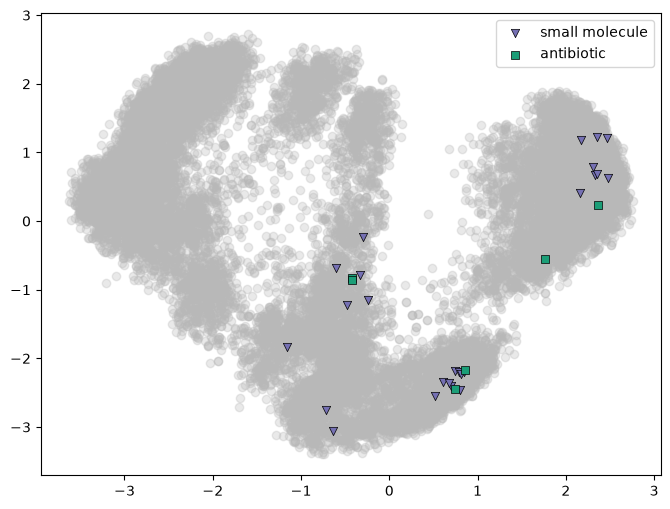

In [18]:
# PCA of embeddings
abx_embs = np.load('../data/abx_embs.npz')
sm_embs = np.load('../data/small_mol_embs.npz')

abx_norm = pd.read_csv('../data/normalized_abx.csv')
sm_norm = pd.read_csv('../data/normalized_small_mol.csv')

abx_to_index, sm_to_index = build_map_indexes(abx_norm, sm_norm)

stacked_embs = np.vstack((abx_embs['embeddings'], sm_embs['embeddings']))

pca_embs = PCA(n_components=2).fit(stacked_embs)

fig, axes = plt.subplots( figsize=(8, 6))

# base scatter plot of all embeddings in grey
axes.scatter(pca_embs.transform(stacked_embs)[:, 0], 
             pca_embs.transform(stacked_embs)[:, 1], 
             color="#b8b8b8", alpha=0.3)


abx_always_present_idx = [abx_to_index[abx] for abx in abx_always_present]
sm_always_present_idx = [sm_to_index[sm] for sm in sm_always_present]

abx_always_present_embs = abx_embs['embeddings'][abx_always_present_idx]
sm_always_present_embs = sm_embs['embeddings'][sm_always_present_idx]

sns.scatterplot(x=pca_embs.transform(sm_always_present_embs)[:, 0],
                y=pca_embs.transform(sm_always_present_embs)[:, 1], marker='v',
                color='#7570b3', edgecolors="black", linewidth=0.5, 
                label='small molecule', alpha=1, ax=axes)

sns.scatterplot(x=pca_embs.transform(abx_always_present_embs)[:, 0],
                y=pca_embs.transform(abx_always_present_embs)[:, 1], 
                marker='s', color='#1b9e77', edgecolors="black", 
                linewidth=0.5, label='antibiotic', alpha=1, ax=axes)

axes.legend()
plt.show()